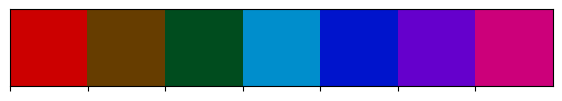

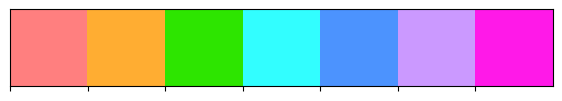

In [1]:
import os
import sys
import torch
import numpy as np
from scipy.integrate import simps
import scipy
import gymnasium as gym
import random
import matplotlib.pylab as plt

SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.policy_analysis import discount_episode_reward, sum_ep_timesteps, set_blind_colors
light_colors, dark_colors = set_blind_colors()
dark_colors += ["y", "gold", "silver", "black", "orange", "gray", "navy", "rosybrown", "lightcyan", "hotpink"]

In [42]:
def bootstrap_ci(data, stat_function=np.mean, n_bootstrap=1000, ci=95):
    """
    Computes the bootstrap confidence interval for a given statistic.
    
    Parameters:
        data (array-like): Sample data.
        stat_function (function): Function to compute the statistic (default: np.mean).
        n_bootstrap (int): Number of bootstrap resamples (default: 1000).
        ci (float): Confidence level (default: 95 for a 95% confidence interval).
    
    Returns:
        tuple: Lower and upper bound of the confidence interval.
    """
    boot_samples = np.random.choice(data, (n_bootstrap, len(data)), replace=True)
    boot_stats = np.apply_along_axis(stat_function, 1, boot_samples)
    
    lower_percentile = (100 - ci) / 2
    upper_percentile = 100 - lower_percentile
    
    lower_bound = np.percentile(boot_stats, lower_percentile)
    upper_bound = np.percentile(boot_stats, upper_percentile)
    
    return np.array([lower_bound, upper_bound])

def load_train_reward(dir: str):
    reward_train_all = np.load(dir + "reward_train_all.npy", allow_pickle=True)[()]["seeds_y_axis"]
    reward_train_mean = np.load(dir + "reward_train_mean.npy")
    reward_train_std = np.load(dir + "reward_train_std.npy")
    reward_train_confidence = np.load(dir + "reward_train_confidence.npy")
    return reward_train_all, reward_train_mean, reward_train_std, reward_train_confidence

def confidence_interval(data, confidence=0.95):
    conf = scipy.stats.sem(data) * scipy.stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return conf

def confidence_interval_2d(data: np.ndarray, confidence: float=0.95):
    confds = []
    for j in range(data.shape[1]):
        k = confidence_interval(data[:, j], confidence)
        confds.append(k)
    return np.array(confds)

In [3]:
grid_size = [10, 10]
n_seeds = 10
dryness = 0.05
gamma = 0.99
ep_window = 11
q_lr = 0.0001
r_lr = 0.0001
n_mdp_action = 6

device = "mps:0"
timesteps_freq = int(5e5)
n_rows, n_colums = grid_size

## hyper-parameters

In [ ]:
timestep_clip = int(3e6)
limit = timestep_clip // timesteps_freq
mean_auc, all_auc = {}, {}
r_lrs = [0.0001, 0.0005, 0.001, 0.005]
q_lrs = [0.0001, 0.0005, 0.001, 0.005]
labels = {0.001: r"$10^{-3}$", 0.005: r"$5*10^{-3}$", 0.0001: r"$10^{-4}$", 0.0005: r"$5*10^{-4}$"}
fig = plt.figure(figsize=(6, 4))
count = 0
for q_lr in q_lrs:
    for r_lr in r_lrs:
        main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/room/window_{}/eps_decay_0.0001".format(n_rows, n_colums, dryness, ep_window)
        log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(q_lr, r_lr)
        legend = r"Q={}, R={}".format(labels[q_lr], labels[r_lr])
        seed_train, mean_train, _, conf_train = load_train_reward(log_dir)
        if len(mean_train) > limit:
            area = simps(mean_train[:limit])
            mean_auc.update({"{}, {}".format(q_lr, r_lr): area})
        else:
            raise ValueError("error")
        seed_auc = np.zeros(n_seeds)
        for see, seed_tr in enumerate(seed_train):
            if len(seed_tr) > limit:
                area = simps(seed_tr[:limit])
                seed_auc[see] = area
            # else:
            #     raise ValueError("error")
        all_auc.update({"{}, {}".format(q_lr, r_lr): seed_auc})
        plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=5,  c=dark_colors[count], alpha=0.7, label=legend)
        plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
        count += 1
plt.xlabel(r"Training Timesteps $(\times 10^6)$", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)
x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.xlim(-50000, timestep_clip)
plt.grid(axis="y")
plt.tight_layout()

In [31]:
for q_lr in [0.005]:
    for r_lr in r_lrs:
        legend = r"Q={}, R={}".format(labels[q_lr], labels[r_lr])
        mean = np.mean(all_auc[str(q_lr) + ", " + str(r_lr)])
        low, high = bootstrap_ci(all_auc[str(q_lr) + ", " + str(r_lr)])
        print(np.round(mean / 10, 2), np.round([low / 10, high / 10], 2))

14.04 [10.94 15.82]
15.36 [14.63 16.14]
11.25 [ 6.58 14.75]
5.51 [1.11 9.96]


## Epslion

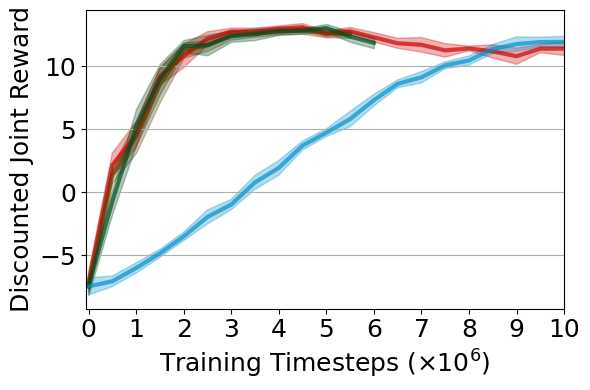

In [60]:
timestep_clip = 10e6
eps = {0.0001: r"$\epsilon$ decay=$10^{-4}$", 1e-05: r"$\epsilon$ decay=$10^{-5}$", 1e-06: r"$\epsilon$ decay=$10^{-6}$",
       1e-07: r"$\epsilon$ decay=$10^{-7}$"}
# eps = {0.0001: r"$\epsilon$ decay=$10^{-4}$"}
fig = plt.figure(figsize=(6, 4))
count = 0
for ep in eps:
    # for base in ["reward_model", "zero_reward", "ignore"]:
    for base in ["reward_model"]:
        main_dir = "../general_models/Plants/{}/{}_{}_channel/dry_{}/window_{}/eps_decay_{}".format(base, n_rows, n_colums, dryness, ep_window, ep)
        log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)
        seed_train, mean_train, _, conf_train = load_train_reward(log_dir)
        # for seed_tr in seed_train:
        #     plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
        plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=3,  c=dark_colors[count], alpha=0.7, label=base)
        plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
        count += 1
    
    
plt.xlabel(r"Training Timesteps $(\times 10^6)$", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)
x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.xlim(-50000, timestep_clip)
plt.grid(axis="y")
plt.tight_layout()
fig.savefig(log_dir + "/binary_eps.pdf", dpi=300)

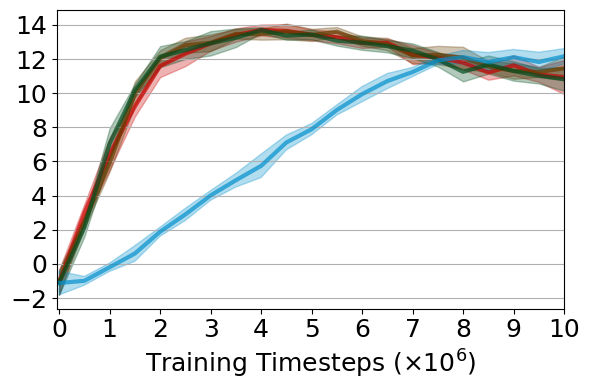

In [59]:
timestep_clip = 10e6
eps = {0.0001: r"$\epsilon$ decay=$10^{-4}$", 1e-05: r"$\epsilon$ decay=$10^{-5}$", 1e-06: r"$\epsilon$ decay=$10^{-6}$",
       1e-07: r"$\epsilon$ decay=$10^{-7}$"}
# eps = {0.0001: r"$\epsilon$ decay=$10^{-4}$"}
fig = plt.figure(figsize=(6, 4))
count = 0
for ep in eps:
    # for base in ["reward_model", "zero_reward", "ignore"]:
    for base in ["reward_model"]:
        main_dir = "../general_models/Plants/{}/{}_{}_channel/dry_{}/room/window_{}/eps_decay_{}".format(base, n_rows, n_colums, dryness, ep_window, ep)
        log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)
        seed_train, mean_train, _, conf_train = load_train_reward(log_dir)
        # for seed_tr in seed_train:
        #     plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
        plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=3,  c=dark_colors[count], alpha=0.7, label=base)
        plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
        count += 1
    
    
plt.xlabel(r"Training Timesteps $(\times 10^6)$", fontsize=18)
x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.xlim(-50000, timestep_clip)
plt.grid(axis="y")
plt.tight_layout()
fig.savefig(log_dir + "/room_eps.pdf", dpi=300)

## Plasticity loss in Mon-MDPs

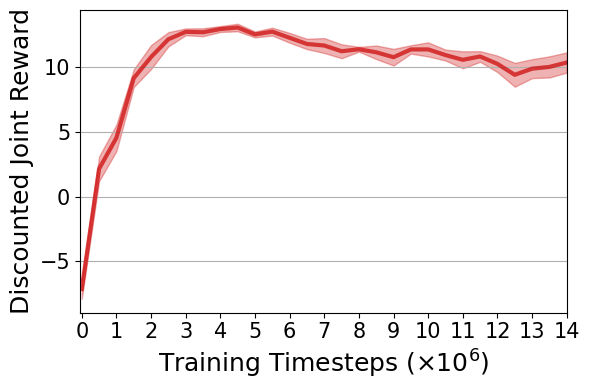

In [47]:
timestep_clip = 14e6
fig = plt.figure(figsize=(6, 4))
count = 0
main_dir = "../general_models/Plants/reward_model/10_10_channel/dry_0.05/window_11/eps_decay_0.0001"
log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(q_lr, r_lr)
train_seeds, mean_train, _, conf_train = load_train_reward(log_dir)
# for seed_tr in train_seeds:
#     plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=3,  c=dark_colors[count], alpha=0.7, label=base)
plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
count += 1


plt.xlabel(r"Training Timesteps $(\times 10^6)$", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)

x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.xlim(-50000, timestep_clip)
plt.yticks(fontsize=15)
plt.grid(axis="y")
# plt.legend(fontsize=12)
plt.tight_layout()
dir_window = "../general_models/Plants/reward_model/10_10_channel/dry_0.05/window_11/eps_decay_0.0001/"

fig.savefig(dir_window + "/binary_plasticity_training_curve.pdf", dpi=300)    

In [49]:
reward_frq = np.load("../general_models/Plants/reward_model/10_10_channel/dry_0.05/window_11/eps_decay_0.0001/q_lr_0.0001/reward_lr_0.0001/training_frequency_ask_moniotred_full.npy")
n_checkpoints = 29
reward_means, reward_conf = np.zeros(n_checkpoints), np.zeros(n_checkpoints)
for i in range(n_checkpoints):
    reward_means[i] = np.mean(reward_frq[:, i, :]) / 100
    reward_conf[i] = confidence_interval(np.mean(reward_frq[:, i, :], 0)) / 100

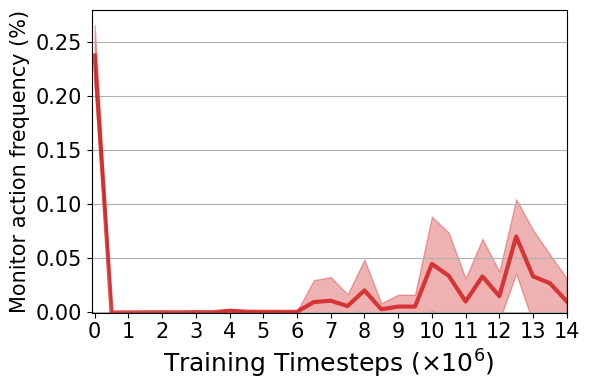

In [51]:
fig = plt.figure(figsize=(6, 4))
count = 0

plt.xlabel(r"Training Timesteps $(\times10^6)$", fontsize=18)
plt.ylabel("Monitor action frequency (%)", fontsize=15)

plt.plot(np.arange(n_checkpoints) * timesteps_freq, reward_means, lw=3,  c=dark_colors[count], alpha=0.7, label="Reward model")
plt.fill_between(np.arange(n_checkpoints) * timesteps_freq, reward_means - reward_conf, reward_means + reward_conf, color=dark_colors[count], alpha=0.3)

x_legend = np.arange(0, n_checkpoints + 2, 2) * 0.5
plt.xticks(np.arange(0, n_checkpoints + 2, 2) * timesteps_freq, x_legend.astype(int), fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis="y")
plt.ylim(-0.0001,)
plt.xlim(-90000, 14e6)
plt.tight_layout()
fig.savefig(dir_window + "/binary_plasticity_frequency_monitor.pdf", dpi=300)    

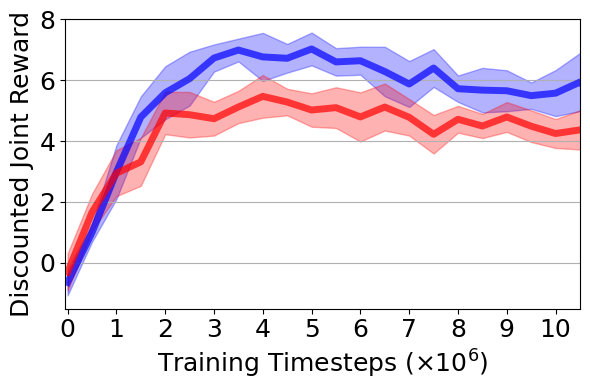

In [48]:
n_seeds = 10
ep_max_length = 100
ep_window = 10

timestep_clip = 10.5e6

discount = np.array([gamma**i for i in range(ep_max_length)])
room_main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/room/window_11/eps_decay_0.0001/".format(
    n_rows, n_colums, dryness)
room_log_dir = room_main_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)

cut_indx = 5 if n_rows == 10 else 3
cut_indx_1 = int(cut_indx * 2)

fig = plt.figure(figsize=(6, 4))
one_seeds, two_seeds, three_seeds = [], [], []
for seed in range(n_seeds):
    agent_pos = np.load(room_log_dir + "/agent_locations_{}.npy".format(seed))
    train_reward = np.load(room_log_dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
    reward_1, reward_2, reward_3 = [], [], []
    
    for ep_train in range(len(agent_pos)):
        ones = np.squeeze(np.argwhere(agent_pos[ep_train, : , 1] < cut_indx))
        twos = np.squeeze(np.argwhere((agent_pos[ep_train, : , 1] > cut_indx) & (agent_pos[ep_train, : , 1] < cut_indx_1)))
    
        reward_1.append(np.sum(np.array(train_reward[ep_train])[ones] * discount[ones]))
        reward_2.append(np.sum(np.array(train_reward[ep_train])[twos] * discount[twos]))
    
    ep_length = ep_max_length * np.ones(len(train_reward))
    ep_timesteps_sum = sum_ep_timesteps(ep_length)
    x_axis = np.arange(ep_length[0], int(ep_timesteps_sum[-1]), timesteps_freq)
    y_axis_1, y_axis_2, y_axis_3 = [], [], []
    for timestep in range(int(ep_length[0]), int(ep_timesteps_sum[-1]), timesteps_freq):
        ind = np.where(ep_timesteps_sum > timestep)[0][0]
        value_1 = np.mean(reward_1[ind - ep_window: ind]) if ind > ep_window else reward_1[ind]
        value_2 = np.mean(reward_2[ind - ep_window: ind]) if ind > ep_window else reward_2[ind]

        y_axis_1.append(value_1)
        y_axis_2.append(value_2)

    one_seeds.append(y_axis_1)
    two_seeds.append(y_axis_2)
lenghts_1 = [len(l) for l in one_seeds]
lenghts_2 = [len(l) for l in two_seeds]

mean_1 = np.mean(np.array([l[:min(lenghts_1)] for l in one_seeds]), 0)
mean_2 = np.mean(np.array([l[:min(lenghts_2)] for l in two_seeds]), 0)

std_1 = confidence_interval_2d(np.array([l[:min(lenghts_1)] for l in one_seeds]))
std_2 = confidence_interval_2d(np.array([l[:min(lenghts_2)] for l in two_seeds]))

plt.plot(np.arange(len(mean_1)) * timesteps_freq, mean_1, lw=5,  c="b", alpha=0.7, label="Zone 1")
plt.fill_between(np.arange(len(mean_1)) * timesteps_freq, mean_1 - std_1, mean_1 + std_1, color="b", alpha=0.3)

plt.plot(np.arange(len(mean_2)) * timesteps_freq, mean_2, lw=5,  c="r", alpha=0.7, label="Zone 2")
plt.fill_between(np.arange(len(mean_2)) * timesteps_freq, mean_2 - std_2, mean_2 + std_2, color="r", alpha=0.3)

plt.xlabel(r"Training Timesteps ($\times10^{6}$)", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)

x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.yticks(fontsize=18) #18
plt.xticks(fontsize=18) #18
plt.xlim(-50000, timestep_clip)
plt.grid(axis="y")
plt.tight_layout()
# fig.savefig(room_main_dir + "room_plasticity_training_curve.pdf", dpi=300)